# Assignment 2 : Language Modeling, BM25 & Evaluation

**Student names**: Brage Andreas Hoven <br>
**Group number**: 99 <br>
**Date**: 2026-10-02

## Important notes
Please read and follow these rules. Submissions that do not fulfill them may be returned.
1. You may work in groups of maximum 2 students.
2. Submit in **.ipynb** format only.
3. The assignment must be typed. Handwritten answers are not accepted.

**On libraries.** The TODO cells are yours to implement. numpy, pandas, scipy.sparse and matplotlib are fine underneath. Do not use libraries that implement a step for you, such as scikit-learn vectorizers or metrics, NLTK tokenizers, or IR evaluation packages.

**Due date**: 02.10.2026 23:59

### What you will do
- Build a **unigram document language model** with a **document-term matrix**.
- Rank documents for queries using **Jelinek-Mercer smoothing**.
- (Optional) Try **Dirichlet** and compare briefly.
- Rank the same queries using **BM25**.
- Evaluate and compare the two models using **Cranfield queries and qrels** (P@k, MAP, MRR).

---
## Dataset

Make sure the Cranfield files are placed next to the notebook:
- `cran.all.1400` — document collection (1400 docs)
- `cran.qry` — queries
- `cranqrel` — relevance judgments (qrels)

> Only the **document parsing** for cran.all.1400 code is provided below. You will implement the rest in the TODO cells.


### Load and parse documents (provided)

Run the cell to parse the Cranfield documents. Update the path so it points to your `cran.all.1400` file.


In [15]:
# Read 'cran.all.1400' and parse the documents into a suitable data structure

CRAN_PATH = r"./task/cran.all.1400"  # <-- change this!

def parse_cranfield(path):
    docs = {}
    current_id = None
    current_field = None
    buffers = {"T": [], "A": [], "B": [], "W": []}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                if current_id is not None:
                    docs[current_id] = {
                        "id": current_id,
                        "title": " ".join(buffers["T"]).strip(),
                        "abstract": " ".join(buffers["W"]).strip()
                    }
                current_id = int(line.split()[1])
                buffers = {k: [] for k in buffers}
                current_field = None
            elif line.startswith("."):
                tag = line[1:].strip()
                current_field = tag if tag in buffers else None
            else:
                if current_field is not None:
                    buffers[current_field].append(line)
    if current_id is not None:
        docs[current_id] = {
            "id": current_id,
            "title": " ".join(buffers["T"]).strip(),
            "abstract": " ".join(buffers["W"]).strip()
        }
    print(f"Parsed {len(docs)} documents.")
    return docs

docs = parse_cranfield(CRAN_PATH)
print(list(docs.items())[:1])  # peek at the first parsed doc

Parsed 1400 documents.
[(1, {'id': 1, 'title': 'experimental investigation of the aerodynamics of a wing in a slipstream .', 'abstract': 'experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free stream to slipstream velocity ratios .  the results were intended in part as an evaluation basis for different theoretical treatments of this problem .   the comparative span loading curves, together with supporting evidence, showed that a substantial part of the lift increment produced by the slipstream was due to a /destalling/ or boundary-layer-control effect .  the integrated remaining lift increment, after subtracting this destalling lift, was found to agree well with a potential flow theory .   an empirical evaluation of the destalling effects was made fo

## 2.1 Ranking Models

You will create a **unigram language model** per document, using a **document-term matrix**, and score queries with **Jelinek-Mercer smoothing**. You will then rank the same queries with **BM25**, using the same matrix.

### 2.1.1 Preprocessing

Implement a simple tokenizer/normalizer (e.g., lowercasing, punctuation removal and stopword removal) and apply it to each document

- Return a list of tokens for each document.


In [16]:
# TODO: Implement preprocessing and apply to all documents

STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same shan't she
she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves then there there's
these they they'd they'll they're they've this those through to too under until up very was wasn't we we'd we'll we're
we've were weren't what what's when when's where where's which while who who's whom why why's with won't would wouldn't
you you'd you'll you're you've your yours yourself yourselves""".split())

# Your code here
import re


def tokenize(text):
    lowercase_text = text.lower()
    text_without_punctuation_and_digits = re.sub(r"[^a-z\s]", " ", lowercase_text)
    raw_tokens = text_without_punctuation_and_digits.split()

    normalized_tokens = []

    for token in raw_tokens:
        if token not in STOPWORDS:
            normalized_tokens.append(token)

    return normalized_tokens


document_tokens = {}

for document_id, document in docs.items():
    full_text = document["title"] + " " + document["abstract"]
    document_tokens[document_id] = tokenize(full_text)

print(f"Tokenized {len(document_tokens)} documents.")


Tokenized 1400 documents.


### 2.1.2 Build the matrix

Construct:
- A vocabulary `term -> column_index`
- A (sparse) **document–term count matrix**
- Document lengths `|d|` and collection (all documents) totals
- Document frequencies `n_t` (number of documents containing the term) and the average document length (needed for BM25)

> Tip: You may use dictionaries or `scipy.sparse` for efficiency.

In [17]:
# TODO: Build vocabulary, doc-term counts (sparse), document lengths, collection totals,
# document frequencies, and average document length
# Your code here
import math
import numpy as np
from scipy.sparse import csr_matrix


unique_terms = set()

for tokens in document_tokens.values():
    for token in tokens:
        unique_terms.add(token)

vocabulary = sorted(unique_terms)
term_to_column = {}

for column_index, term in enumerate(vocabulary):
    term_to_column[term] = column_index

document_ids = sorted(docs.keys())
document_id_to_row = {}

for row_index, document_id in enumerate(document_ids):
    document_id_to_row[document_id] = row_index

number_of_documents = len(document_ids)
number_of_terms = len(vocabulary)
row_indices = []
column_indices = []
term_frequencies = []

for document_id, tokens in document_tokens.items():
    row_index = document_id_to_row[document_id]
    term_counts = {}

    for token in tokens:
        if token not in term_counts:
            term_counts[token] = 0

        term_counts[token] += 1

    for term, raw_frequency in term_counts.items():
        row_indices.append(row_index)
        column_indices.append(term_to_column[term])
        term_frequencies.append(raw_frequency)

document_term_matrix = csr_matrix(
    (term_frequencies, (row_indices, column_indices)),
    shape=(number_of_documents, number_of_terms),
    dtype=float
)

document_lengths = np.asarray(document_term_matrix.sum(axis=1)).ravel()
collection_term_counts = np.asarray(document_term_matrix.sum(axis=0)).ravel()
collection_length = float(collection_term_counts.sum())
document_frequencies = np.asarray((document_term_matrix > 0).sum(axis=0)).ravel()
average_document_length = float(document_lengths.mean())
collection_probabilities = collection_term_counts / collection_length

print("Document-term matrix shape:", document_term_matrix.shape)
print("Collection length:", int(collection_length))
print("Average document length:", average_document_length)


Document-term matrix shape: (1400, 6934)
Collection length: 141060
Average document length: 100.75714285714285


### 2.1.3 Rank with **Jelinek-Mercer smoothing**

Implement query likelihood scoring with Jelinek-Mercer smoothing:

$\hat{P}(t \mid M_d) = \lambda \hat{P}_{\text{mle}}(t \mid M_d) + (1 - \lambda)\hat{P}_{\text{mle}}(t \mid M_c), \ \lambda = 0.5$



In [18]:
""" TODO: Create a function for implementing query likelihood scoring with Jelinek Mercer smoothing (λ=0.5), 
using the formula above."""

def jelinek_smoothing(query: str):
    # Your code here
    query_tokens = tokenize(query)
    document_scores = np.zeros(number_of_documents)
    smoothing_weight = 0.5

    for term in query_tokens:
        # Terms outside the vocabulary have no collection probability.
        if term not in term_to_column:
            continue

        column_index = term_to_column[term]
        term_counts = document_term_matrix.getcol(column_index).toarray().ravel()
        document_probabilities = np.zeros(number_of_documents)
        np.divide(
            term_counts, document_lengths,
            out=document_probabilities, where=document_lengths > 0
        )
        smoothed_probabilities = (
            smoothing_weight * document_probabilities
            + (1 - smoothing_weight) * collection_probabilities[column_index]
        )
        document_scores += np.log(smoothed_probabilities)

    scored_documents = []

    for row_index, document_id in enumerate(document_ids):
        scored_documents.append((document_id, float(document_scores[row_index])))

    scored_documents.sort(key=lambda document_score: document_score[1], reverse=True)

    ranked_document_ids = []

    for document_id, _similarity_score in scored_documents:
        ranked_document_ids.append(document_id)

    return ranked_document_ids

In [19]:
# Do not change this code
queries_assignment2 = [
  "gas pressure",
  "structural aeroelastic flight high speed aircraft",
  "heat conduction composite slabs",
  "boundary layer control",
  "compressible flow nozzle",
  "combustion chamber injection",
  "laminar turbulent transition",
  "fatigue crack growth",
  "wing tip vortices",
  "propulsion efficiency"
]

In [20]:
# Run Jelinek-Mercer smoothing on queries in batch (print top-10 results for each), using the function you created
def run_batch_smoothing(queries):
    results = {}
    for i, q in enumerate(queries, 1):
        res = jelinek_smoothing(q)
        results[f"Q{i}"] = res
    return results

jelinek_results = run_batch_smoothing(queries_assignment2)

for qid, res in jelinek_results.items():
    print(qid, "=>", res[:10])


Q1 => [169, 183, 1003, 1312, 1143, 1315, 975, 1274, 1319, 1139]
Q2 => [12, 141, 746, 51, 875, 1169, 1170, 884, 14, 1263]
Q3 => [399, 5, 144, 485, 181, 542, 582, 1073, 119, 91]
Q4 => [265, 1205, 1288, 416, 3, 974, 4, 1349, 342, 933]
Q5 => [118, 389, 775, 965, 217, 326, 941, 984, 1187, 539]
Q6 => [1143, 1241, 1254, 1180, 595, 635, 1195, 696, 691, 1269]
Q7 => [418, 558, 337, 96, 207, 526, 959, 1264, 1287, 9]
Q8 => [1196, 768, 884, 726, 883, 558, 330, 865, 835, 909]
Q9 => [675, 433, 246, 434, 288, 289, 793, 222, 1342, 902]
Q10 => [968, 1328, 1380, 1092, 592, 182, 578, 1151, 1270, 1211]


#### Dirichlet

If you have time, also implement Dirichlet smoothing and briefly compare the top-10 lists for the first query in the queries_assignment2 list


In [21]:
# TODO (Optional): Implement Dirichlet scoring and compare with Jelinek-Mercer
# Your code here
def dirichlet_smoothing(query: str):
    query_tokens = tokenize(query)
    document_scores = np.zeros(number_of_documents)
    smoothing_strength = 2000

    for term in query_tokens:
        if term not in term_to_column:
            continue

        column_index = term_to_column[term]
        term_counts = document_term_matrix.getcol(column_index).toarray().ravel()
        smoothed_probabilities = (
            term_counts + smoothing_strength * collection_probabilities[column_index]
        ) / (document_lengths + smoothing_strength)
        document_scores += np.log(smoothed_probabilities)

    scored_documents = []

    for row_index, document_id in enumerate(document_ids):
        scored_documents.append((document_id, float(document_scores[row_index])))

    scored_documents.sort(key=lambda document_score: document_score[1], reverse=True)

    ranked_document_ids = []

    for document_id, similarity_score in scored_documents:
        ranked_document_ids.append(document_id)

    return ranked_document_ids


first_query = queries_assignment2[0]
jelinek_top_documents = jelinek_smoothing(first_query)[:10]
dirichlet_top_documents = dirichlet_smoothing(first_query)[:10]
shared_documents = set(jelinek_top_documents).intersection(dirichlet_top_documents)

print("First query:", first_query)
print("Jelinek-Mercer top-10:", jelinek_top_documents)
print("Dirichlet top-10:", dirichlet_top_documents)
print("Documents shared by the two top-10 lists:", len(shared_documents))
print("Jelinek-Mercer uses a fixed mixture weight of 0.5.")
print("Dirichlet with mu=2000 smooths shorter documents more strongly towards the collection.")


First query: gas pressure
Jelinek-Mercer top-10: [169, 183, 1003, 1312, 1143, 1315, 975, 1274, 1319, 1139]
Dirichlet top-10: [185, 169, 1274, 166, 1319, 1286, 493, 110, 1003, 975]
Documents shared by the two top-10 lists: 5
Jelinek-Mercer uses a fixed mixture weight of 0.5.
Dirichlet with mu=2000 smooths shorter documents more strongly towards the collection.


### 2.1.4 Rank with **BM25**

Implement BM25 ranking, using the formulas below:

$B_{i,j} = \dfrac{(K_1 + 1) \cdot tf_{i,j}}{K_1 \cdot \left[(1 - b) + b \cdot \dfrac{len(d_i)}{avg\_doclen}\right] + tf_{i,j}}$

$sim_{BM25}(d_i, q) \sim \sum\limits_{w_j \in q \,\wedge\, w_j \in d_i} B_{i,j} \cdot \log\left(\dfrac{N - n_j + 0.5}{n_j + 0.5}\right)$

where $tf_{i,j}$ is the frequency of term $w_j$ in document $d_i$, $len(d_i)$ is the document length, $avg\_doclen$ is the average document length in the collection, $N$ is the number of documents and $n_j$ is the number of documents containing $w_j$. Use $K_1 = 1$ and $b = 0.75$.

In [22]:
""" TODO: Create a function for implementing BM25 ranking (K1=1, b=0.75),
using the formulas above."""

def bm25_ranking(query: str):
    # Your code here
    query_tokens = tokenize(query)
    document_scores = np.zeros(number_of_documents)
    saturation_parameter = 1
    length_normalization_weight = 0.75
    length_normalization = saturation_parameter * (
        (1 - length_normalization_weight)
        + length_normalization_weight * document_lengths / average_document_length
    )

    for term in query_tokens:
        if term not in term_to_column:
            continue

        column_index = term_to_column[term]
        term_counts = document_term_matrix.getcol(column_index).toarray().ravel()
        document_frequency = int(document_frequencies[column_index])
        inverse_document_frequency = math.log(
            (number_of_documents - document_frequency + 0.5)
            / (document_frequency + 0.5)
        )
        term_weights = (
            (saturation_parameter + 1) * term_counts
            / (length_normalization + term_counts)
        )
        document_scores += term_weights * inverse_document_frequency

    scored_documents = []

    for row_index, document_id in enumerate(document_ids):
        scored_documents.append((document_id, float(document_scores[row_index])))

    scored_documents.sort(key=lambda document_score: document_score[1], reverse=True)

    ranked_document_ids = []

    for document_id, similarity_score in scored_documents:
        ranked_document_ids.append(document_id)

    return ranked_document_ids
    raise NotImplementedError("Implement BM25 ranking here")

In [23]:
# Run BM25 on queries in batch (print top-10 results for each), using the function you created
def run_batch_bm25(queries):
    results = {}
    for i, q in enumerate(queries, 1):
        res = bm25_ranking(q)
        results[f"Q{i}"] = res
    return results

bm25_results = run_batch_bm25(queries_assignment2)

for qid, res in bm25_results.items():
    print(qid, "=>", res[:10])

Q1 => [169, 1003, 1312, 975, 1143, 166, 1274, 1319, 427, 665]
Q2 => [12, 746, 141, 51, 875, 1170, 14, 1169, 884, 724]
Q3 => [399, 5, 144, 485, 181, 542, 582, 91, 90, 119]
Q4 => [265, 1205, 1288, 416, 974, 1349, 368, 638, 451, 748]
Q5 => [118, 1366, 131, 136, 1230, 942, 1187, 173, 172, 970]
Q6 => [1143, 1241, 1254, 1180, 635, 691, 1269, 1072, 1374, 974]
Q7 => [418, 96, 558, 337, 9, 315, 1264, 959, 536, 207]
Q8 => [768, 884, 726, 883, 1196, 865, 867, 881, 767, 75]
Q9 => [675, 433, 288, 246, 434, 1342, 289, 222, 902, 709]
Q10 => [968, 1328, 1380, 1092, 592, 578, 1019, 182, 1151, 1270]


## 2.2 Evaluation (Cranfield queries + qrels)

Evaluate your two ranking models using **Cranfield**:
- Parse **queries** from `cran.qry`
- Parse **relevance judgments** from `cranqrel`
- Compute **P@k (k=5,10)**, **MAP (Mean Average Precision)**, and **MRR (Mean Reciprocal Rank)** over all queries

### 2.2.1 Parse `cran.qry` and `cranqrel`

- Create `queries[qid] = "text"` by parsing `cran.qry`, where `qid` is the position of the query in the file (1, 2, ..., 225), not the number after `.I`
- Create `qrels[qid] = set(relevant_doc_ids)` by parsing `cranqrel`, with the IDs as integers

The `.I` numbers in `cran.qry` have gaps (001, 002, 004, 008, ...), but `cranqrel` refers to queries by position. For example, the third query in the file is `.I 004`, and its judgments are listed under query 3.

The third column of `cranqrel` is a relevance code. Treat codes 1 to 4 as relevant, and ignore lines with code `-1`. Documents not listed for a query are not relevant.

Run the check cell below your code to confirm the parsing is correct.

In [24]:
# TODO: Parse cran.qry and cranqrel into convenient data structures
# Your code here
from pathlib import Path


# Support running from the notebook folder or the repository root.
data_directory = Path(CRAN_PATH).parent

if not (data_directory / "cran.qry").exists():
    data_directory = Path("assignment-2")

queries = {}
current_query_id = None
current_field = None
query_lines = []

with open(data_directory / "cran.qry", "r", encoding="utf-8") as query_file:
    for line in query_file:
        line = line.strip()

        if line.startswith(".I "):
            if current_query_id is not None:
                queries[current_query_id] = " ".join(query_lines).strip()

            current_query_id = len(queries) + 1
            current_field = None
            query_lines = []
        elif line.startswith("."):
            current_field = line[1:].strip()
        else:
            if current_field == "W":
                query_lines.append(line)

if current_query_id is not None:
    queries[current_query_id] = " ".join(query_lines).strip()

qrels = {}

for query_id in queries:
    qrels[query_id] = set()

with open(data_directory / "cranqrel", "r", encoding="utf-8") as relevance_file:
    for line in relevance_file:
        if line.strip() == "":
            continue

        query_id, document_id, relevance_code = map(int, line.split())

        if 1 <= relevance_code <= 4:
            qrels[query_id].add(document_id)

print("Parsed", len(queries), "queries and their relevance judgments.")


Parsed 225 queries and their relevance judgments.


In [25]:
# Check your parsing. Do not change this code
assert sorted(queries) == list(range(1, 226)), "Number the queries 1 to 225 by their position in cran.qry"
assert "conduction" in str(queries[3]).lower(), "Query 3 should be about heat conduction in composite slabs"
assert 184 in qrels[1] and 486 not in qrels[1], "Check qrels: IDs should be integers, and lines with code -1 ignored"
print("Parsing looks correct")

Parsing looks correct


### 2.2.2 Implement metrics: P@k, MAP, MRR

Write functions to compute:
- Precision@k (for **k=5** and **k=10**)
- Mean Average Precision (MAP)
- Mean Reciprocal Rank (MRR)


In [26]:
# TODO: Implement P@k (k=5,10), MAP, and MRR
# Your code here
def precision_at_k(ranked_document_ids, relevant_document_ids, cutoff):
    if cutoff <= 0:
        raise ValueError("The cutoff must be positive.")

    number_of_relevant_documents = 0

    for document_id in ranked_document_ids[:cutoff]:
        if document_id in relevant_document_ids:
            number_of_relevant_documents += 1

    return number_of_relevant_documents / cutoff


def average_precision(ranked_document_ids, relevant_document_ids):
    if len(relevant_document_ids) == 0:
        return 0.0

    number_of_relevant_documents = 0
    precision_sum = 0.0

    for rank, document_id in enumerate(ranked_document_ids, 1):
        if document_id in relevant_document_ids:
            number_of_relevant_documents += 1
            precision_sum += number_of_relevant_documents / rank

    return precision_sum / len(relevant_document_ids)


def reciprocal_rank(ranked_document_ids, relevant_document_ids):
    for rank, document_id in enumerate(ranked_document_ids, 1):
        if document_id in relevant_document_ids:
            return 1 / rank

    return 0.0


def mean_average_precision(rankings, relevance_judgments):
    if len(relevance_judgments) == 0:
        return 0.0

    precision_sum = 0.0

    for query_id, relevant_document_ids in relevance_judgments.items():
        ranked_document_ids = rankings.get(query_id, [])
        precision_sum += average_precision(ranked_document_ids, relevant_document_ids)

    return precision_sum / len(relevance_judgments)


def mean_reciprocal_rank(rankings, relevance_judgments):
    if len(relevance_judgments) == 0:
        return 0.0

    reciprocal_rank_sum = 0.0

    for query_id, relevant_document_ids in relevance_judgments.items():
        ranked_document_ids = rankings.get(query_id, [])
        reciprocal_rank_sum += reciprocal_rank(ranked_document_ids, relevant_document_ids)

    return reciprocal_rank_sum / len(relevance_judgments)


### 2.2.3 Evaluate your runs

- For **all queries**, generate rankings with your **Jelinek-Mercer** model and with your **BM25** model
- Report aggregate metrics for both models: P@5, P@10, MAP, MRR

In [27]:
# TODO: Run retrieval for all queries with both models and compute P@5, P@10, MAP, and MRR for each
# Your code here
jelinek_rankings = {}
bm25_rankings = {}

for query_id, query in queries.items():
    jelinek_rankings[query_id] = jelinek_smoothing(query)
    bm25_rankings[query_id] = bm25_ranking(query)


def evaluate_rankings(rankings, relevance_judgments):
    precision_at_five_sum = 0.0
    precision_at_ten_sum = 0.0

    for query_id, relevant_document_ids in relevance_judgments.items():
        ranked_document_ids = rankings.get(query_id, [])
        precision_at_five_sum += precision_at_k(ranked_document_ids, relevant_document_ids, 5)
        precision_at_ten_sum += precision_at_k(ranked_document_ids, relevant_document_ids, 10)

    number_of_queries = len(relevance_judgments)

    if number_of_queries == 0:
        return {"P@5": 0.0, "P@10": 0.0, "MAP": 0.0, "MRR": 0.0}

    return {
        "P@5": precision_at_five_sum / number_of_queries,
        "P@10": precision_at_ten_sum / number_of_queries,
        "MAP": mean_average_precision(rankings, relevance_judgments),
        "MRR": mean_reciprocal_rank(rankings, relevance_judgments)
    }


jelinek_metrics = evaluate_rankings(jelinek_rankings, qrels)
bm25_metrics = evaluate_rankings(bm25_rankings, qrels)

for model_name, metrics in [("Jelinek-Mercer", jelinek_metrics), ("BM25", bm25_metrics)]:
    print(model_name)

    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")


Jelinek-Mercer
  P@5: 0.3058
  P@10: 0.2124
  MAP: 0.2727
  MRR: 0.5142
BM25
  P@5: 0.3227
  P@10: 0.2276
  MAP: 0.2844
  MRR: 0.5100


### 2.2.4 Interpolated precision–recall curves (11‑point)

- Using your **rankings from task 2.2.3** and the **relevance judgments (`cranqrel`)**, compute **precision** and **recall** at each rank for each query.
- For the 11 standard recall levels `R = {0.0, 0.1, ..., 1.0}`, compute the **interpolated precision** at level `r` as the **maximum precision** observed at any point with recall ≥ `r`.
- **Report/plot** the **11‑point interpolated precision–recall curve** across queries for **both models** (Jelinek-Mercer and BM25) in the same figure (and optionally a few per‑query curves).

Recall  Jelinek-Mercer  BM25
0.0     0.5621          0.5612
0.1     0.5294          0.5280
0.2     0.4668          0.4764
0.3     0.3845          0.4008
0.4     0.3277          0.3509
0.5     0.2840          0.3094
0.6     0.2024          0.2239
0.7     0.1567          0.1717
0.8     0.1345          0.1452
0.9     0.1049          0.1121
1.0     0.0983          0.1056


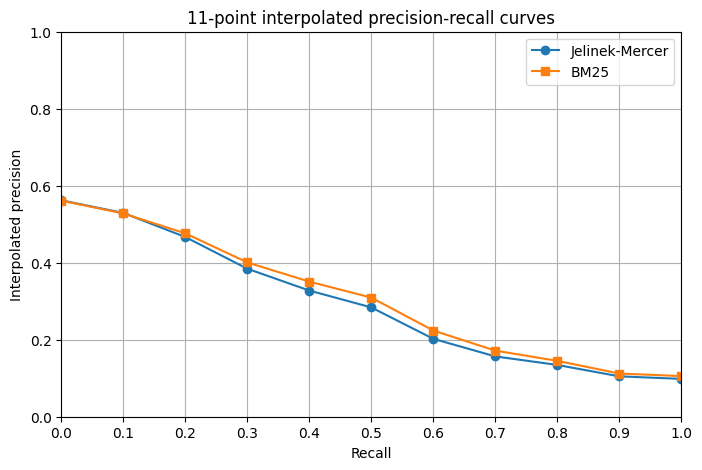

In [28]:
# TODO: Compute the 11-point interpolated precision–recall for each query, for both models

# Your code here
import matplotlib.pyplot as plt


recall_levels = np.arange(11) / 10


def interpolated_precision_recall(ranked_document_ids, relevant_document_ids):
    interpolated_precisions = np.zeros(len(recall_levels))

    if len(relevant_document_ids) == 0:
        return interpolated_precisions

    number_of_relevant_documents = 0
    precisions = []
    recalls = []

    for rank, document_id in enumerate(ranked_document_ids, 1):
        if document_id in relevant_document_ids:
            number_of_relevant_documents += 1

        precisions.append(number_of_relevant_documents / rank)
        recalls.append(number_of_relevant_documents / len(relevant_document_ids))

    for level_index, recall_level in enumerate(recall_levels):
        maximum_precision = 0.0

        for precision, recall in zip(precisions, recalls):
            if recall >= recall_level:
                maximum_precision = max(maximum_precision, precision)

        interpolated_precisions[level_index] = maximum_precision

    return interpolated_precisions


def mean_interpolated_precision_recall(rankings, relevance_judgments):
    precision_sum = np.zeros(len(recall_levels))

    if len(relevance_judgments) == 0:
        return precision_sum

    for query_id, relevant_document_ids in relevance_judgments.items():
        ranked_document_ids = rankings.get(query_id, [])
        precision_sum += interpolated_precision_recall(ranked_document_ids, relevant_document_ids)

    return precision_sum / len(relevance_judgments)


jelinek_precision_curve = mean_interpolated_precision_recall(jelinek_rankings, qrels)
bm25_precision_curve = mean_interpolated_precision_recall(bm25_rankings, qrels)

print("Recall  Jelinek-Mercer  BM25")

for level_index, recall_level in enumerate(recall_levels):
    print(
        f"{recall_level:.1f}     "
        f"{jelinek_precision_curve[level_index]:.4f}          "
        f"{bm25_precision_curve[level_index]:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(recall_levels, jelinek_precision_curve, marker="o", label="Jelinek-Mercer")
plt.plot(recall_levels, bm25_precision_curve, marker="s", label="BM25")
plt.xlabel("Recall")
plt.ylabel("Interpolated precision")
plt.title("11-point interpolated precision-recall curves")
plt.xticks(recall_levels)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()
